# Filtering and Parameter Estimation in Nonlinear State Space Models 

This python notebook investigates the Kalman Filter, the Kalman Smoother, the EM algorithm and the EKF

## Filtering and Smoothing

### Kalman Filter Class

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter class for Linear-Gaussian State Space Models
class KalmanFilterLGSSM:
    """
    Kalman filter for a (possibly time-varying) Linear-Gaussian State Space Model:

        z_{t+1} = F_t z_t + w_t,      w_t ~ N(0, Q_t)
        x_t     = H_t z_t + v_t,      v_t ~ N(0, R_t)

    The class supports both:
    1. Full filtering output (predicted means/covariances, filtered means/covariances),
    2. Step-by-step recursion when only the current covariance or state estimate is needed.

    Parameters:

    F, Q, H, R :
    Model matrices. Each may either be fixed numpy arrays or functions of time t.
    m0 : 
    Initial mean of the latent state.
    C0 : 
    Initial covariance of the latent state.
    """

    def __init__(self, F, Q, H, R, m0, C0):
        self.F = F
        self.Q = Q
        self.H = H
        self.R = R

        self.m0 = np.asarray(m0, dtype=float).reshape(-1)
        self.C0 = np.asarray(C0, dtype=float)

        self.m = self.m0.copy()
        self.C = self.C0.copy()
        self.n = self.m.shape[0]

    def _mat(self, M, t):
        return M(t) if callable(M) else M

    def reset(self, m0=None, C0=None):
        """
        Reset the filter to its initial state or to a new supplied state.

        This is useful when the same KalmanFilterLGSSM object is reused
        for multiple experiments.
        """
        if m0 is None:
            self.m = self.m0.copy()
        else:
            self.m = np.asarray(m0, dtype=float).reshape(-1)

        if C0 is None:
            self.C = self.C0.copy()
        else:
            self.C = np.asarray(C0, dtype=float)

    # Prediction step of Kalman filter: returns F m_t and F C_t F^T + Q
    def predict(self, t):
        F = self._mat(self.F, t)
        Q = self._mat(self.Q, t)

        m_hat = F @ self.m
        C_hat = F @ self.C @ F.T + Q
        return m_hat, C_hat

    # Update step of Kalman filter
    def update(self, x, m_hat, C_hat, t):
        H = self._mat(self.H, t)
        R = self._mat(self.R, t)

        x = np.asarray(x, dtype=float).reshape(-1)

        # Innovation d_t = x_t - H_t \hat m_t and its covariance S_t
        d = x - (H @ m_hat)
        S = H @ C_hat @ H.T + R

        # Kalman gain K_t = C_hat H^T S^{-1}
        K = C_hat @ H.T @ np.linalg.solve(S, np.eye(S.shape[0]))

        # Posterior mean and covariance
        m_new = m_hat + K @ d
        C_new = (np.eye(self.n) - K @ H) @ C_hat

        return m_new, C_new, d, S, K

    # Perform one step of Kalman filtering: predict + update
    def step(self, x, t):
        m_hat, C_hat = self.predict(t)
        m_new, C_new, d, S, K = self.update(x, m_hat, C_hat, t)

        self.m, self.C = m_new, C_new

        return {
            "m_hat": m_hat,
            "C_hat": C_hat,
            "innovation": d,
            "S": S,
            "K": K,
            "m": m_new,
            "C": C_new,
        }

    # Kalman filter recursion over a full observation sequence
    def filter(self, xs, t0=0):
        xs = [np.asarray(x, dtype=float).reshape(-1) for x in xs]

        m_hats, C_hats = [], []
        ms, Cs = [], []
        innovations, Ss, Ks = [], [], []

        t = t0
        for x in xs:
            info = self.step(x, t)

            m_hats.append(info["m_hat"])
            C_hats.append(info["C_hat"])
            ms.append(info["m"])
            Cs.append(info["C"])
            innovations.append(info["innovation"])
            Ss.append(info["S"])
            Ks.append(info["K"])

            t += 1

        return {
            "m_hat": np.array(m_hats, dtype=float),
            "C_hat": np.array(C_hats, dtype=float),
            "m": np.array(ms, dtype=float),
            "C": np.array(Cs, dtype=float),
            "innovation": np.array(innovations, dtype=float),
            "S": np.array(Ss, dtype=float),
            "K": np.array(Ks, dtype=float),
        }



Tracking a one dimensional particle, under going a constant velocity model (Example 1 in Section 2.3)

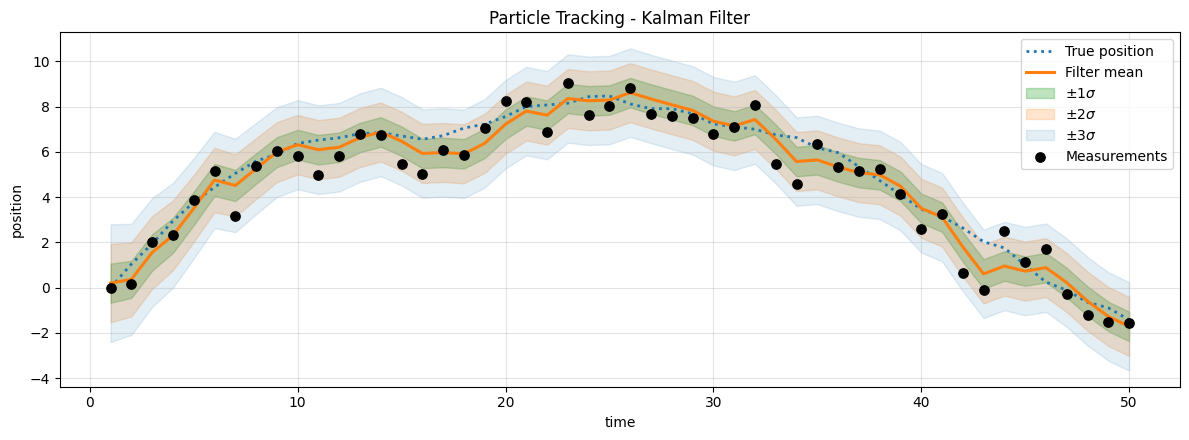

In [8]:


# Example 1: Particle tracking with uncertainty bands

# random seed for reproducibility
rng = np.random.default_rng(7)

# Time steps and time step size
T = 50
dt = 1.0

# State transition + measurement matrices
F = np.array([[1.0, dt],
              [0.0, 1.0]])
H = np.array([[1.0, 0.0]])

# Process noise + measurement noise covariances
Q = np.array([[0.02, 0.0],
              [0.0, 0.02]])
R = np.array([[1.0]])  

# True initial state z = (position, velocity)
z0_true = np.array([0.0, 1.0])

# Initial mean and covariance
m0 = np.array([0.0, 0.8])
C0 = np.array([[2.0, 0.0],
               [0.0, 1.0]])

# Generate true trajectory + noisy measurements
zs = np.zeros((T, 2))   # true latent states
xs = np.zeros((T, 1))   # measurements (position only)

z = z0_true.copy()
for t in range(T):
    # Measurement equation: x_t = H z_t + v_t
    v = rng.normal(0.0, np.sqrt(R[0, 0]), size=(1,))
    xs[t] = (H @ z).reshape(-1) + v

    # Store true latent state
    zs[t] = z

    # State evolution: z_{t+1} = F z_t + w_t
    if t < T - 1:
        w = rng.multivariate_normal(mean=np.zeros(2), cov=Q)
        z = (F @ z) + w


# Run Kalman filter
kf = KalmanFilterLGSSM(F=F, Q=Q, H=H, R=R, m0=m0, C0=C0)
out = kf.filter(xs)

# Extract filter means and covariances
m_filt = out["m"]       
C_filt = out["C"]       

pos_mean = m_filt[:, 0]
pos_std = np.sqrt(C_filt[:, 0, 0])  # posterior standard deviation for position

tgrid = np.arange(1, T + 1)

# Plot: true position, measurements, filter estimate + 1σ/2σ/3σ bands
plt.figure(figsize=(12, 4.5))
plt.title("Particle Tracking - Kalman Filter")

plt.plot(
    tgrid,
    zs[:, 0],
    linestyle=":",
    linewidth=2.0,
    label="True position"
)

plt.plot(
    tgrid,
    pos_mean,
    linewidth=2.2,
    label="Filter mean"
)

# 1st standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 1.0 * pos_std,
    pos_mean + 1.0 * pos_std,
    alpha=0.30,
    color="tab:green",
    label=r"$\pm 1\sigma$"
)

# 2nd standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 2.0 * pos_std,
    pos_mean + 2.0 * pos_std,
    alpha=0.20,
    color="tab:orange",
    label=r"$\pm 2\sigma$"
)

# 3rd standard deviation band
plt.fill_between(
    tgrid,
    pos_mean - 3.0 * pos_std,
    pos_mean + 3.0 * pos_std,
    alpha=0.12,
    color="tab:blue",
    label=r"$\pm 3\sigma$"
)

plt.scatter(
    tgrid,
    xs[:, 0],
    s=45,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()




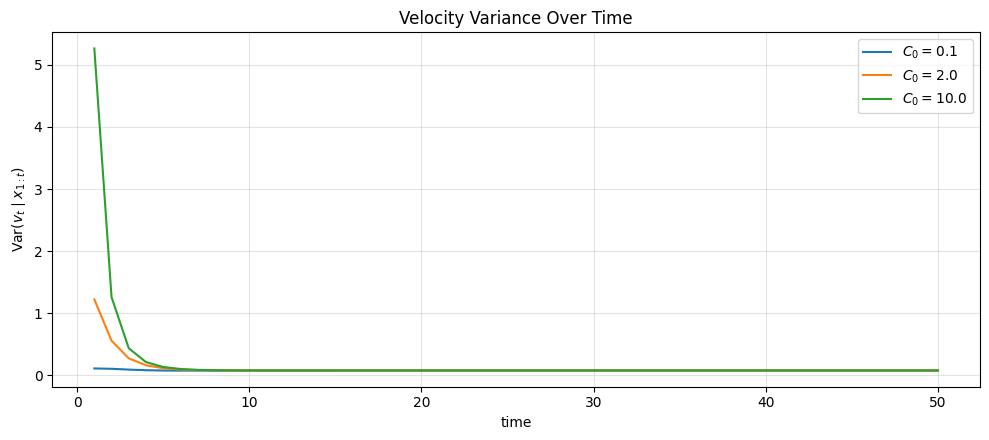

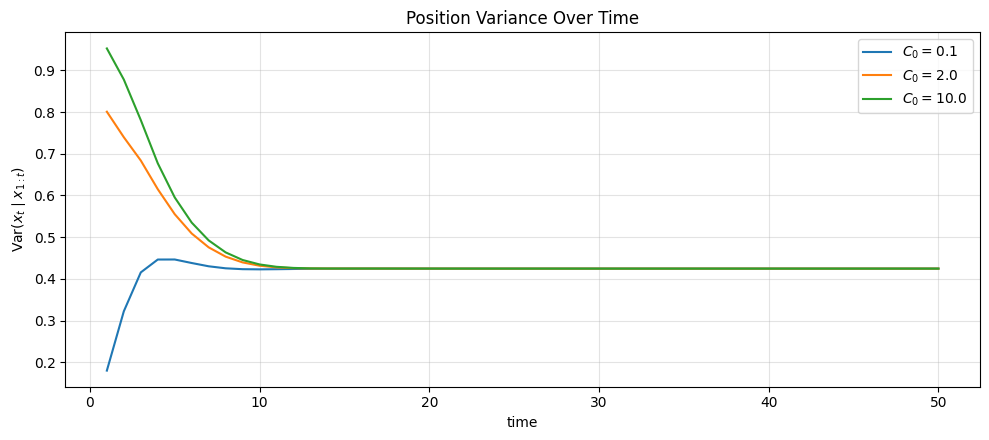

In [3]:

# Example 2: Effect of different initial covariances on filtering uncertainty

# Fixed measurement sequence (same for all runs)
rng = np.random.default_rng(7)
xs = rng.normal(0.0, np.sqrt(R[0, 0]), size=(T, 1))

# Different initial covariances
initial_covariances = {
    "$C_0 = 0.1$": np.diag([0.1, 0.1]),
    "$C_0 = 2.0$": np.diag([2.0, 2.0]),
    "$C_0 = 10.0$": np.diag([10.0, 10.0]),
}

position_var = {}
velocity_var = {}

for label, C0 in initial_covariances.items():
    kf = KalmanFilterLGSSM(F=F, Q=Q, H=H, R=R, m0=m0, C0=C0)
    out = kf.filter(xs)

    # Extract posterior variances of position and velocity
    position_var[label] = out["C"][:, 0, 0]
    velocity_var[label] = out["C"][:, 1, 1]

time = np.arange(1, T + 1)

# Plot 1: Velocity variance
plt.figure(figsize=(10, 4.5))
for label, var in velocity_var.items():
    plt.plot(time, var, label=label)

plt.xlabel("time")
plt.ylabel(r"$\mathrm{Var}(v_t \mid x_{1:t})$")
plt.title("Velocity Variance Over Time")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Position variance
plt.figure(figsize=(10, 4.5))
for label, var in position_var.items():
    plt.plot(time, var, label=label)

plt.xlabel("time")
plt.ylabel(r"$\mathrm{Var}(x_t \mid x_{1:t})$")
plt.title("Position Variance Over Time")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

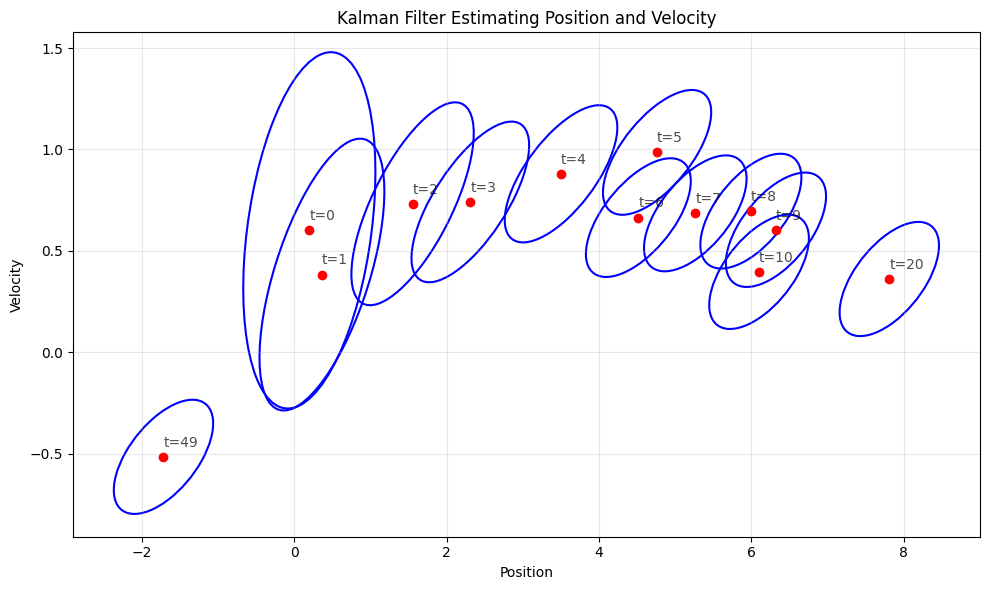

In [4]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Kalman Filter Estimating Position and Velocity")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.grid(True, alpha=0.3)

# Show only the means corresponding to the plotted ellipses
steps = [0, 1, 2, 3, 4, 5,6, 7, 8, 9, 10, 20, 49]
selected_means = m_filt[steps]


ax.scatter(selected_means[:, 0], selected_means[:, 1], color="red", zorder=3)

for t in steps:
    mean = m_filt[t]
    cov = C_filt[t]

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor="blue",
        facecolor="none",
        lw=1.5
    )
    ax.add_patch(ellipse)

    ax.text(mean[0], mean[1] + 0.05, f"t={t}", fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

In [5]:
def draw_uncertainty_ellipsoids(ax, means, covs, step=10, scale=2.0, alpha=0.10):
    """
    Draw full 3D covariance ellipsoids along the estimated trajectory.

    Parameters
    ----------
    ax : 3D matplotlib axis
    means : array, shape (T, state_dim)
        Filtered state means.
    covs : array, shape (T, state_dim, state_dim)
        Filtered state covariances.
    step : int
        Plot one ellipsoid every `step` time steps.
    scale : float
        Size multiplier. For example, scale=2 draws a 2-sigma ellipsoid.
    alpha : float
        Transparency of the ellipsoid surface.
    """
    # Unit sphere parameterisation
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 20)

    sphere_x = np.outer(np.cos(u), np.sin(v))
    sphere_y = np.outer(np.sin(u), np.sin(v))
    sphere_z = np.outer(np.ones_like(u), np.cos(v))

    sphere = np.stack([sphere_x, sphere_y, sphere_z], axis=0)  # shape (3, nu, nv)

    for t in range(0, len(means), step):
        # Position mean: take x, y, z components from [x, vx, y, vy, z, vz]
        mean = means[t, [0, 2, 4]]

        # Position covariance block
        Cpos = covs[t][np.ix_([0, 2, 4], [0, 2, 4])]

        # Eigen-decomposition of covariance
        vals, vecs = np.linalg.eigh(Cpos)

        # Sort by largest variance first
        order = vals.argsort()[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        # Semi-axis lengths of the ellipsoid
        radii = scale * np.sqrt(np.maximum(vals, 0.0))

        # Transform the unit sphere into the covariance ellipsoid
        ellipsoid = (
            vecs @ np.diag(radii) @ sphere.reshape(3, -1)
        ).reshape(3, sphere.shape[1], sphere.shape[2])

        X = ellipsoid[0] + mean[0]
        Y = ellipsoid[1] + mean[1]
        Z = ellipsoid[2] + mean[2]

        ax.plot_surface(
            X, Y, Z,
            color="lightskyblue",
            alpha=alpha,
            linewidth=0,
            shade=True
        )

c:\Github\Kalman-Filter-Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


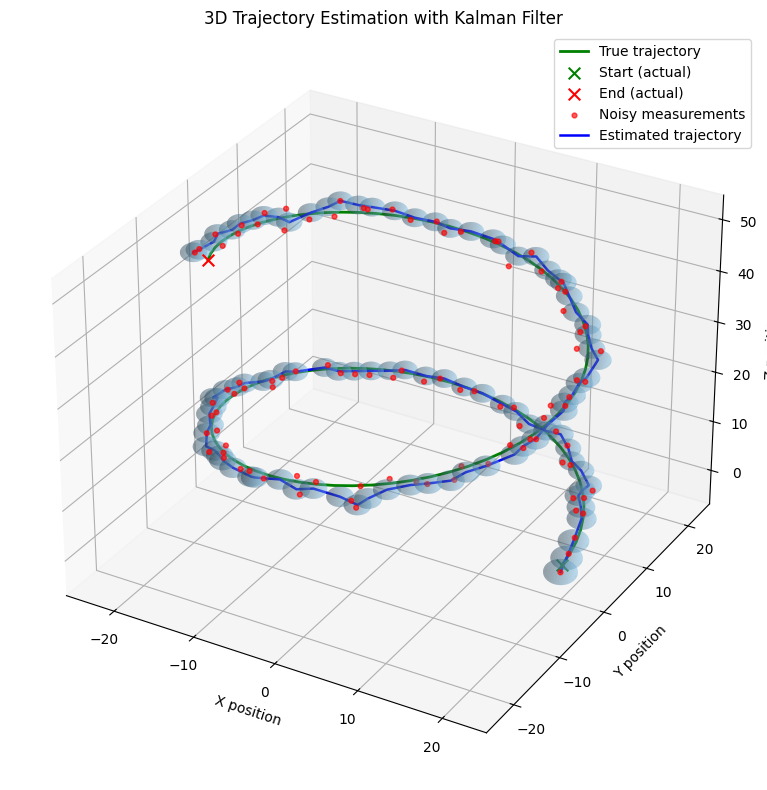

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# 3D tracking example 
# State: [x, vx, y, vy, z, vz]
# Observation: [x, y, z]


rng = np.random.default_rng(7)

# Time grid
T = 100
dt = 1.0
tgrid = np.arange(T)

# True 3D trajectory: a helix
radius = 20.0
omega = 0.1

true_x = radius * np.cos(omega * tgrid)
true_y = radius * np.sin(omega * tgrid)
true_z = 0.5 * tgrid

# Noisy position measurements
obs_std = 1.0
xs_3d = np.column_stack([
    true_x + rng.normal(0.0, obs_std, size=T),
    true_y + rng.normal(0.0, obs_std, size=T),
    true_z + rng.normal(0.0, obs_std, size=T),
])

# Constant-velocity state transition applied separately in x, y, z
F3 = np.array([
    [1.0, dt, 0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, dt, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0, dt],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
])

# Observe positions only
H3 = np.array([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
])

# Small process noise, isotropic measurement noise
Q3 = 0.05 * np.eye(6)
R3 = (obs_std**2) * np.eye(3)

# Initial estimate:
# start near the first measurement and use a rough initial velocity guess
m0_3d = np.array([
    xs_3d[0, 0], 0.0,
    xs_3d[0, 1], 0.0,
    xs_3d[0, 2], 0.5,
])

C0_3d = np.diag([4.0, 2.0, 4.0, 2.0, 4.0, 2.0])

# Run the same Kalman filter class
kf_3d = KalmanFilterLGSSM(F=F3, Q=Q3, H=H3, R=R3, m0=m0_3d, C0=C0_3d)
out_3d = kf_3d.filter(xs_3d)

m_filt_3d = out_3d["m"]

# Extract filtered positions
x_est = m_filt_3d[:, 0]
y_est = m_filt_3d[:, 2]
z_est = m_filt_3d[:, 4]


# Plot true trajectory, noisy observations, and Kalman estimate
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# True path
ax.plot(true_x, true_y, true_z, color="green", linewidth=2.0, label="True trajectory")

# Start / end markers
ax.scatter(true_x[0], true_y[0], true_z[0], color="green", marker="x", s=70, label="Start (actual)")
ax.scatter(true_x[-1], true_y[-1], true_z[-1], color="red", marker="x", s=70, label="End (actual)")

# Noisy measurements
ax.scatter(xs_3d[:, 0], xs_3d[:, 1], xs_3d[:, 2], color="red", s=12, alpha=0.65, label="Noisy measurements")

# Filtered estimate
ax.plot(x_est, y_est, z_est, color="blue", linewidth=1.8, label="Estimated trajectory")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Z position")
ax.set_title("3D Trajectory Estimation with Kalman Filter")
ax.legend()

#draw uncertainty tube
draw_uncertainty_ellipsoids(ax, m_filt_3d, out_3d["C"], step=1, scale=2.0, alpha=0.3)
plt.tight_layout()
plt.show()

### Kalman Smoother

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\967670478.py:4: SyntaxWarning: invalid escape sequence '\h'
  """


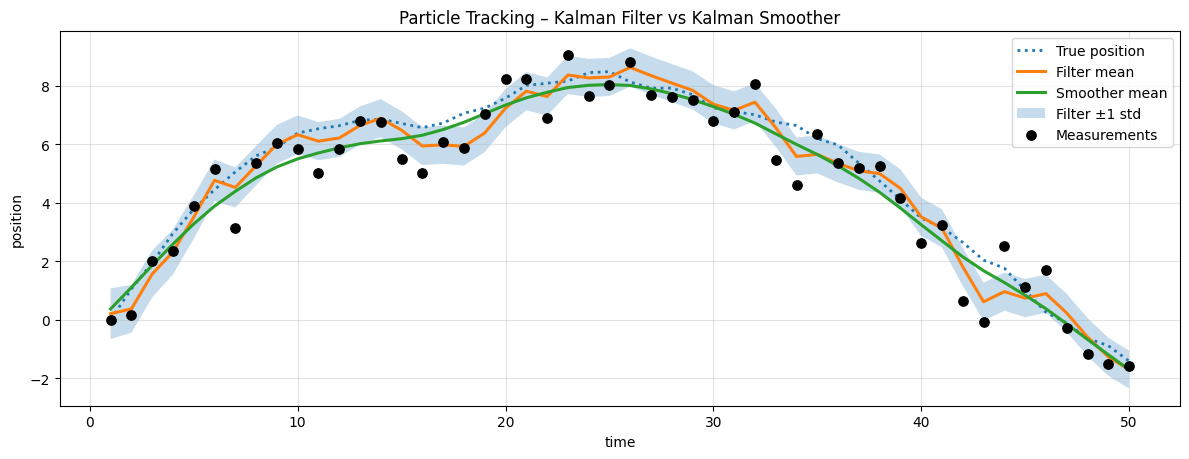

In [9]:
# Kalman Smoother

def kalman_smoother(F, m_pred, C_pred, m_filt, C_filt):
    """
    Kalman smoother 

    Inputs:
      m_pred[t] = \hat{m}, C_pred[t] = \hat{C}
      m_filt[t] = m_t,   C_filt[t] = C_t
    Outputs:
      m_smooth[t] = m^s, C_smooth[t] = C^s
    """
    F = np.asarray(F, dtype=float)
    T, n = m_filt.shape

    m_smooth = np.zeros_like(m_filt)
    C_smooth = np.zeros_like(C_filt)

    # final time: smoothed = filtered
    m_smooth[-1] = m_filt[-1]
    C_smooth[-1] = C_filt[-1]

    # backward pass
    for t in range(T - 2, -1, -1):
        # C_pred[t+1] is C_{t+1|t}
        J = C_filt[t] @ F.T @ np.linalg.solve(C_pred[t + 1], np.eye(n))
        m_smooth[t] = m_filt[t] + J @ (m_smooth[t + 1] - m_pred[t + 1])
        C_smooth[t] = C_filt[t] + J @ (C_smooth[t + 1] - C_pred[t + 1]) @ J.T

    return m_smooth, C_smooth


m_pred = out["m_hat"]
C_pred = out["C_hat"]

m_smooth, C_smooth = kalman_smoother(F, m_pred, C_pred, m_filt, C_filt)

# Extract position series
tgrid = np.arange(1, T + 1)

true_pos = zs[:, 0]
meas_pos = xs[:, 0]

filt_pos = m_filt[:, 0]
smooth_pos = m_smooth[:, 0]

# Kalman Filter confidence interval (±1 std on position)
filt_pos_std = np.sqrt(C_filt[:, 0, 0])


# Plot

plt.figure(figsize=(12, 4.7))
plt.title("Particle Tracking – Kalman Filter vs Kalman Smoother")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.plot(tgrid, filt_pos, linewidth=2.2, label="Filter mean")
plt.plot(tgrid, smooth_pos, linewidth=2.2, label="Smoother mean")

plt.fill_between(
    tgrid,
    filt_pos - filt_pos_std,
    filt_pos + filt_pos_std,
    alpha=0.25,
    label="Filter ±1 std"
)

plt.scatter(
    tgrid,
    meas_pos,
    s=45,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\1709346760.py:19: SyntaxWarning: invalid escape sequence '\s'
  label="Filter ±1 $\sigma$ "
C:\Users\othma\AppData\Local\Temp\ipykernel_24072\1709346760.py:28: SyntaxWarning: invalid escape sequence '\s'
  label="Smoother ±1 $\sigma$"


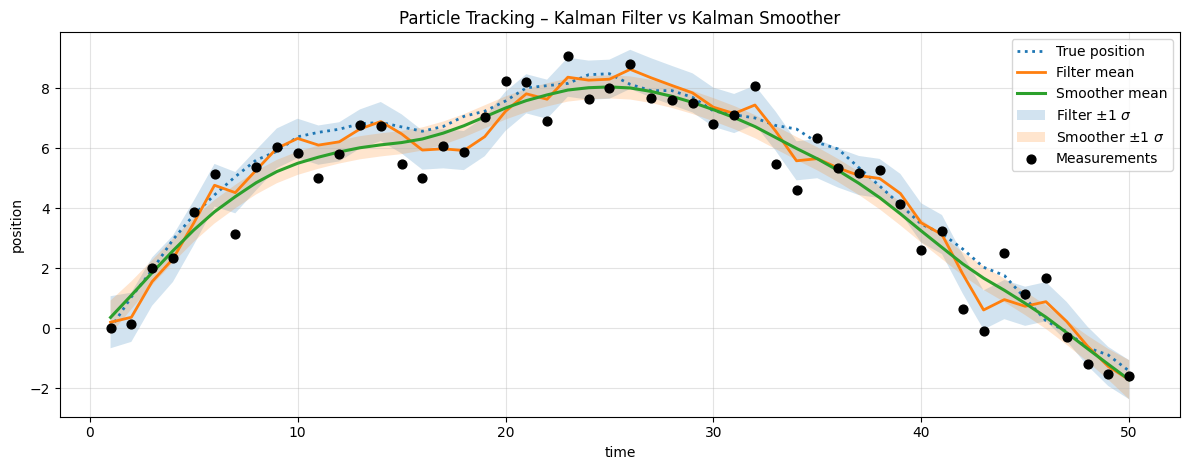

In [10]:
# Plot 1: filter vs smoother with uncertainty bands

filt_pos_std = np.sqrt(C_filt[:, 0, 0])
smooth_pos_std = np.sqrt(C_smooth[:, 0, 0])

plt.figure(figsize=(12, 4.8))
plt.title("Particle Tracking – Kalman Filter vs Kalman Smoother")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.plot(tgrid, filt_pos, linewidth=2.0, label="Filter mean")
plt.plot(tgrid, smooth_pos, linewidth=2.2, label="Smoother mean")

# Filter uncertainty
plt.fill_between(
    tgrid,
    filt_pos - filt_pos_std,
    filt_pos + filt_pos_std,
    alpha=0.20,
    label="Filter ±1 $\sigma$ "
)

# Smoother uncertainty
plt.fill_between(
    tgrid,
    smooth_pos - smooth_pos_std,
    smooth_pos + smooth_pos_std,
    alpha=0.20,
    label="Smoother ±1 $\sigma$"
)

plt.scatter(
    tgrid,
    meas_pos,
    s=40,
    color="black",
    zorder=5,
    label="Measurements"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

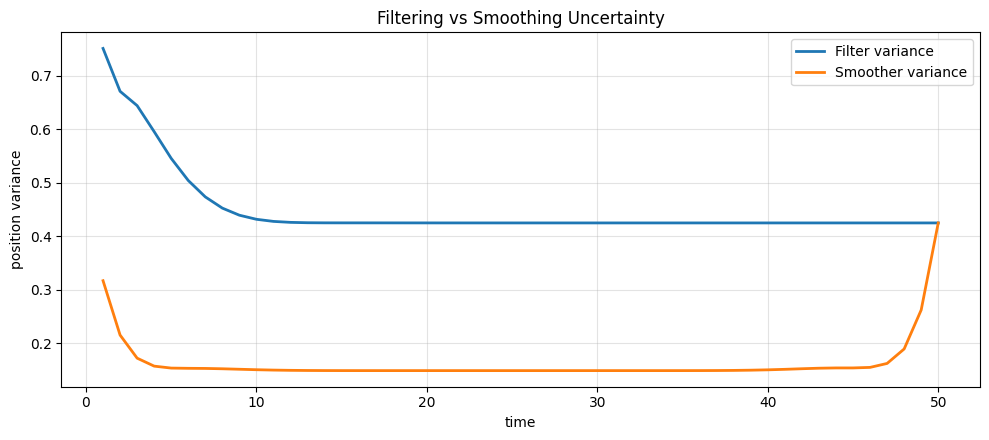

In [11]:
# Plot 2: filtering vs smoothing uncertainty over time

plt.figure(figsize=(10, 4.5))
plt.plot(tgrid, C_filt[:, 0, 0], linewidth=2.0, label="Filter variance")
plt.plot(tgrid, C_smooth[:, 0, 0], linewidth=2.0, label="Smoother variance")

plt.xlabel("time")
plt.ylabel("position variance")
plt.title("Filtering vs Smoothing Uncertainty")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

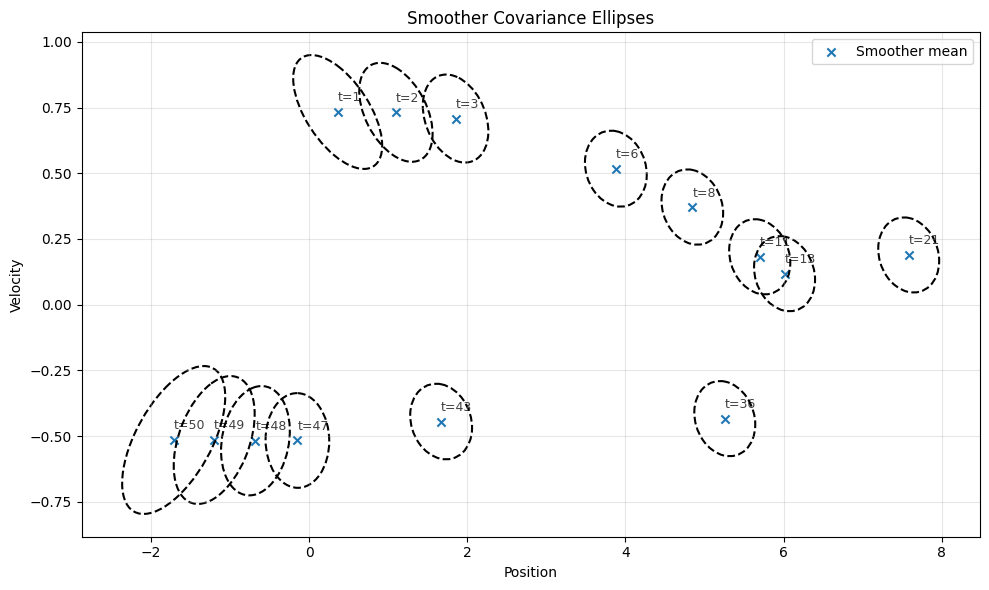

In [12]:
# Plot 3: filter and smoother covariance ellipses in (position, velocity) space

from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_title("Smoother Covariance Ellipses")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.grid(True, alpha=0.3)

# Select a few times to avoid clutter
steps = [0, 1, 2, 5, 7, 10, 12, 20, T-15, T-8, T-4, T-3, T-2, T - 1]

# Means at selected times
ax.scatter(m_smooth[steps, 0], m_smooth[steps, 1], s=35, marker="x", label="Smoother mean")

for t in steps:
    # # --- Filter ellipse ---
    # mean_f = m_filt[t]
    # cov_f = C_filt[t]

    # vals_f, vecs_f = np.linalg.eigh(cov_f)
    # order_f = vals_f.argsort()[::-1]
    # vals_f = vals_f[order_f]
    # vecs_f = vecs_f[:, order_f]

    # angle_f = np.degrees(np.arctan2(vecs_f[1, 0], vecs_f[0, 0]))
    # width_f, height_f = 2 * np.sqrt(vals_f)

    # ell_f = Ellipse(
    #     xy=mean_f,
    #     width=width_f,
    #     height=height_f,
    #     angle=angle_f,  
    #     fill=False,
    #     lw=1.5,
    # )
    # ax.add_patch(ell_f)

    # --- Smoother ellipse ---
    mean_s = m_smooth[t]
    cov_s = C_smooth[t]

    vals_s, vecs_s = np.linalg.eigh(cov_s)
    order_s = vals_s.argsort()[::-1]
    vals_s = vals_s[order_s]
    vecs_s = vecs_s[:, order_s]

    angle_s = np.degrees(np.arctan2(vecs_s[1, 0], vecs_s[0, 0]))
    width_s, height_s = 2 * np.sqrt(vals_s)

    ell_s = Ellipse(
        xy=mean_s,
        width=width_s,
        height=height_s,
        angle=angle_s,
        fill=False,
        lw=1.5,
        linestyle="--"
    )
    ax.add_patch(ell_s)

    # Label the time once near the smoother mean
    ax.text(mean_s[0], mean_s[1] + 0.04, f"t={t+1}", fontsize=9, alpha=0.75)

plt.legend()
plt.tight_layout()
plt.show()

## Expectation Maximisation

In [13]:
import numpy as np


def kalman_filter_em(xs, F, Q, H, R, m0, C0):
    """
    Kalman filter with storage of predicted and filtered moments.

    Here xs has shape (T, d), with x_t observing z_t for t = 0, ..., T-1.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    m_pred = np.zeros((T, n))
    C_pred = np.zeros((T, n, n))
    m_filt = np.zeros((T, n))
    C_filt = np.zeros((T, n, n))
    K_arr = np.zeros((T, n, d))

    loglik = 0.0

    # t = 0: update prior with x_0
    m_pred[0] = m0
    C_pred[0] = C0

    innov = xs[0] - H @ m_pred[0]
    S = H @ C_pred[0] @ H.T + R
    K = C_pred[0] @ H.T @ np.linalg.inv(S)

    m_filt[0] = m_pred[0] + K @ innov
    C_filt[0] = (np.eye(n) - K @ H) @ C_pred[0]
    K_arr[0] = K

    loglik += -0.5 * (
        d * np.log(2 * np.pi)
        + np.log(np.linalg.det(S))
        + innov.T @ np.linalg.solve(S, innov)
    )

    # t = 1, ..., T-1
    for t in range(1, T):
        m_pred[t] = F @ m_filt[t - 1]
        C_pred[t] = F @ C_filt[t - 1] @ F.T + Q

        innov = xs[t] - H @ m_pred[t]
        S = H @ C_pred[t] @ H.T + R
        K = C_pred[t] @ H.T @ np.linalg.inv(S)

        m_filt[t] = m_pred[t] + K @ innov
        C_filt[t] = (np.eye(n) - K @ H) @ C_pred[t]
        K_arr[t] = K

        loglik += -0.5 * (
            d * np.log(2 * np.pi)
            + np.log(np.linalg.det(S))
            + innov.T @ np.linalg.solve(S, innov)
        )

    return {
        "m_pred": m_pred,
        "C_pred": C_pred,
        "m_filt": m_filt,
        "C_filt": C_filt,
        "K": K_arr,
        "loglik": loglik,
    }


def kalman_smoother_em(F, H, filt_out):
    """
    RTS smoother with lag-one smoothed covariances.

    Returns:
      m_smooth[t]  = E[z_t | x_{0:T-1}]
      C_smooth[t]  = Cov(z_t | x_{0:T-1}]
      C_lag[t]     = Cov(z_t, z_{t-1} | x_{0:T-1}] for t >= 1
    """
    m_pred = filt_out["m_pred"]
    C_pred = filt_out["C_pred"]
    m_filt = filt_out["m_filt"]
    C_filt = filt_out["C_filt"]
    K_arr = filt_out["K"]

    T, n = m_filt.shape

    m_smooth = np.zeros_like(m_filt)
    C_smooth = np.zeros_like(C_filt)
    J = np.zeros((T - 1, n, n))

    # C_lag[t] = Cov(z_t, z_{t-1} | x_{0:T-1}) for t = 1, ..., T-1
    C_lag = np.zeros((T, n, n))

    m_smooth[-1] = m_filt[-1]
    C_smooth[-1] = C_filt[-1]

    for t in range(T - 2, -1, -1):
        J[t] = C_filt[t] @ F.T @ np.linalg.inv(C_pred[t + 1])
        m_smooth[t] = m_filt[t] + J[t] @ (m_smooth[t + 1] - m_pred[t + 1])
        C_smooth[t] = C_filt[t] + J[t] @ (C_smooth[t + 1] - C_pred[t + 1]) @ J[t].T

    # Base case for lag-one covariance
    if T >= 2:
        C_lag[T - 1] = (np.eye(n) - K_arr[T - 1] @ H) @ F @ C_filt[T - 2]

    # Backward recursion for lag-one covariance
    for t in range(T - 2, 0, -1):
        C_lag[t] = (
            C_filt[t] @ J[t - 1].T
            + J[t] @ (C_lag[t + 1] - F @ C_filt[t]) @ J[t - 1].T
        )

    return {
        "m_smooth": m_smooth,
        "C_smooth": C_smooth,
        "C_lag": C_lag,
        "J": J,
    }


def em_lgssm(xs, F_init, Q_init, H_init, R_init, m0_init, C0_init,
             tol=1e-4, max_iter=100, verbose=True):
    """
    EM for a time-invariant LGSSM.

    Updates (m0, C0, F, Q, H, R) using the closed-form formulas from the
    smoothing moments.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0_init.shape[0]

    F = np.asarray(F_init, dtype=float).copy()
    Q = np.asarray(Q_init, dtype=float).copy()
    H = np.asarray(H_init, dtype=float).copy()
    R = np.asarray(R_init, dtype=float).copy()
    m0 = np.asarray(m0_init, dtype=float).copy()
    C0 = np.asarray(C0_init, dtype=float).copy()

    history = {
        "loglik": [],
        "F": [],
        "Q": [],
        "H": [],
        "R": [],
        "m0": [],
        "C0": [],
    }

    for n_iter in range(max_iter):
        # E-step
        filt_out = kalman_filter_em(xs, F, Q, H, R, m0, C0)
        smooth_out = kalman_smoother_em(F, H, filt_out)

        m_s = smooth_out["m_smooth"]
        C_s = smooth_out["C_smooth"]
        C_lag = smooth_out["C_lag"]

        # Sufficient statistics
        A = np.zeros((n, n))
        B = np.zeros((n, n))
        C = np.zeros((n, n))
        XZ = np.zeros((d, n))
        ZZ = np.zeros((n, n))

        for t in range(1, T):
            A += C_s[t - 1] + np.outer(m_s[t - 1], m_s[t - 1])
            B += C_lag[t] + np.outer(m_s[t], m_s[t - 1])
            C += C_s[t] + np.outer(m_s[t], m_s[t])

        for t in range(T):
            XZ += np.outer(xs[t], m_s[t])
            ZZ += C_s[t] + np.outer(m_s[t], m_s[t])

        # M-step
        m0_new = m_s[0]
        C0_new = C_s[0]

        F_new = B @ np.linalg.inv(A)
        Q_new = (C - B @ F_new.T - F_new @ B.T + F_new @ A @ F_new.T) / (T - 1)
        H_new = XZ @ np.linalg.inv(ZZ)

        R_new = np.zeros((d, d))
        for t in range(T):
            diff = xs[t] - H_new @ m_s[t]
            R_new += np.outer(diff, diff) + H_new @ C_s[t] @ H_new.T
        R_new /= T

        # Symmetrise covariance estimates
        Q_new = 0.5 * (Q_new + Q_new.T)
        R_new = 0.5 * (R_new + R_new.T)
        C0_new = 0.5 * (C0_new + C0_new.T)

        # Store history
        history["loglik"].append(filt_out["loglik"])
        history["F"].append(F.copy())
        history["Q"].append(Q.copy())
        history["H"].append(H.copy())
        history["R"].append(R.copy())
        history["m0"].append(m0.copy())
        history["C0"].append(C0.copy())

        # Convergence check
        theta_old = np.concatenate([
            m0.ravel(), C0.ravel(), F.ravel(), Q.ravel(), H.ravel(), R.ravel()
        ])
        theta_new = np.concatenate([
            m0_new.ravel(), C0_new.ravel(), F_new.ravel(), Q_new.ravel(), H_new.ravel(), R_new.ravel()
        ])

        diff = np.linalg.norm(theta_new - theta_old)

        if verbose:
            print(f"iter {n_iter:2d} | loglik = {filt_out['loglik']:.3f} | diff = {diff:.6e}")

        m0, C0, F, Q, H, R = m0_new, C0_new, F_new, Q_new, H_new, R_new

        if diff <= tol:
            break

    return {
        "m0": m0,
        "C0": C0,
        "F": F,
        "Q": Q,
        "H": H,
        "R": R,
        "history": history,
        "filter_out": filt_out,
        "smooth_out": smooth_out,
    }

In [14]:
# Use the same observations from the constant velocity example
# xs has shape (T, 1)

# Initial parameter guess
F_init = np.array([[1.0, 0.5],
                   [0.0, 1.0]])

Q_init = np.array([[0.10, 0.0],
                   [0.0, 0.10]])

H_init = np.array([[1.0, 0.0]])

R_init = np.array([[2.0]])

m0_init = np.array([0.0, 0.0])

C0_init = np.array([[5.0, 0.0],
                    [0.0, 5.0]])

em_out = em_lgssm(
    xs=xs,
    F_init=F_init,
    Q_init=Q_init,
    H_init=H_init,
    R_init=R_init,
    m0_init=m0_init,
    C0_init=C0_init,
    tol=1e-5,
    max_iter=50,
    verbose=True
)

F_em = em_out["F"]
Q_em = em_out["Q"]
H_em = em_out["H"]
R_em = em_out["R"]
m0_em = em_out["m0"]
C0_em = em_out["C0"]

print("\nEstimated parameters")
print("m0 =\n", m0_em)
print("C0 =\n", C0_em)
print("F =\n", F_em)
print("Q =\n", Q_em)
print("H =\n", H_em)
print("R =\n", R_em)

iter  0 | loglik = -87.094 | diff = 6.598577e+00
iter  1 | loglik = -75.191 | diff = 6.845270e-01
iter  2 | loglik = -73.385 | diff = 2.635606e-01
iter  3 | loglik = -72.897 | diff = 1.336168e-01
iter  4 | loglik = -72.661 | diff = 7.991059e-02
iter  5 | loglik = -72.505 | diff = 5.309034e-02
iter  6 | loglik = -72.384 | diff = 3.781354e-02
iter  7 | loglik = -72.286 | diff = 2.828873e-02
iter  8 | loglik = -72.201 | diff = 2.196315e-02
iter  9 | loglik = -72.127 | diff = 1.756746e-02
iter 10 | loglik = -72.061 | diff = 1.440956e-02
iter 11 | loglik = -72.000 | diff = 1.208412e-02
iter 12 | loglik = -71.945 | diff = 1.033966e-02
iter 13 | loglik = -71.893 | diff = 9.012619e-03
iter 14 | loglik = -71.846 | diff = 7.992224e-03
iter 15 | loglik = -71.801 | diff = 7.200868e-03
iter 16 | loglik = -71.758 | diff = 6.582630e-03
iter 17 | loglik = -71.718 | diff = 6.096312e-03
iter 18 | loglik = -71.679 | diff = 5.711067e-03
iter 19 | loglik = -71.642 | diff = 5.403537e-03
iter 20 | loglik = -

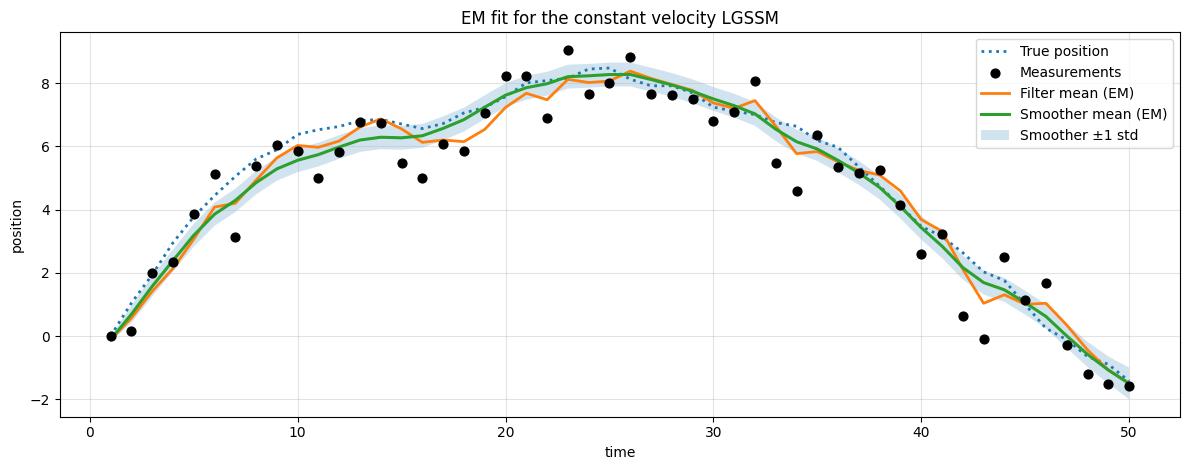

In [15]:
# Run one final filter/smoother using the EM estimates
filt_em = kalman_filter_em(xs, F_em, Q_em, H_em, R_em, m0_em, C0_em)
smooth_em = kalman_smoother_em(F_em, H_em, filt_em)

m_filt_em = filt_em["m_filt"]
C_filt_em = filt_em["C_filt"]
m_smooth_em = smooth_em["m_smooth"]
C_smooth_em = smooth_em["C_smooth"]

pos_filt_em = m_filt_em[:, 0]
pos_smooth_em = m_smooth_em[:, 0]

pos_filt_em_std = np.sqrt(C_filt_em[:, 0, 0])
pos_smooth_em_std = np.sqrt(C_smooth_em[:, 0, 0])

plt.figure(figsize=(12, 4.8))
plt.title("EM fit for the constant velocity LGSSM")

plt.plot(tgrid, true_pos, linestyle=":", linewidth=2.0, label="True position")
plt.scatter(tgrid, meas_pos, s=40, color="black", zorder=5, label="Measurements")

plt.plot(tgrid, pos_filt_em, linewidth=2.0, label="Filter mean (EM)")
plt.plot(tgrid, pos_smooth_em, linewidth=2.2, label="Smoother mean (EM)")

plt.fill_between(
    tgrid,
    pos_smooth_em - pos_smooth_em_std,
    pos_smooth_em + pos_smooth_em_std,
    alpha=0.20,
    label="Smoother ±1 std"
)

plt.xlabel("time")
plt.ylabel("position")
plt.grid(True, alpha=0.35)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [16]:

# Log-likelihood for the LGSSM with fixed parameters except q and r


def kalman_loglik(xs, F, Q, H, R, m0, C0):
    """
    Compute log p(x_{1:T} | theta) via the Kalman filter.
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    m = m0.copy()
    C = C0.copy()

    loglik = 0.0

    for t in range(T):
        # prediction
        m_pred = F @ m
        C_pred = F @ C @ F.T + Q

        # innovation
        innov = xs[t] - H @ m_pred
        S = H @ C_pred @ H.T + R

        loglik += -0.5 * (
            d * np.log(2 * np.pi)
            + np.log(np.linalg.det(S))
            + innov.T @ np.linalg.solve(S, innov)
        )

        # update
        K = C_pred @ H.T @ np.linalg.inv(S)
        m = m_pred + K @ innov
        C = (np.eye(n) - K @ H) @ C_pred

    return float(loglik)


def make_Q_R(q, r):
    """
    Build Q and R from scalar variances q and r.
    """
    Q = np.array([[q, 0.0],
                  [0.0, q]])
    R = np.array([[r]])
    return Q, R


# EM restricted to q and r only
# All other parameters are fixed


def em_q_r_only(xs, F, H, m0, C0, q_init, r_init, tol=1e-6, max_iter=50):
    """
    Run EM updating only:
      q in Q = q I
      r in R = [r]

    Returns the EM path in (log q, log r).
    """
    xs = np.asarray(xs, dtype=float)
    T, d = xs.shape
    n = m0.shape[0]

    q = float(q_init)
    r = float(r_init)

    path = []
    loglik_path = []

    for _ in range(max_iter):
        Q, R = make_Q_R(q, r)

        # E-step
        filt_out = kalman_filter_em(xs, F, Q, H, R, m0, C0)
        smooth_out = kalman_smoother_em(F, H, filt_out)

        m_s = smooth_out["m_smooth"]
        C_s = smooth_out["C_smooth"]
        C_lag = smooth_out["C_lag"]

        # record current iterate
        path.append((np.log(q), np.log(r)))
        loglik_path.append(filt_out["loglik"])

        # M-step for q
        S_q = np.zeros((n, n))
        for t in range(1, T):
            Ezzt = C_s[t] + np.outer(m_s[t], m_s[t])
            Ezzlag = C_lag[t] + np.outer(m_s[t], m_s[t - 1])
            Ezzprev = C_s[t - 1] + np.outer(m_s[t - 1], m_s[t - 1])

            S_q += Ezzt - F @ Ezzlag.T - Ezzlag @ F.T + F @ Ezzprev @ F.T

        Q_new = S_q / (T - 1)

        # constrain Q to q I
        q_new = np.trace(Q_new) / n

        # M-step for r
        S_r = 0.0
        for t in range(T):
            diff = xs[t] - H @ m_s[t]
            term = diff.T @ diff + H @ C_s[t] @ H.T
            S_r += term.item()

        r_new = S_r / T

        # convergence
        diff_param = np.sqrt((q_new - q) ** 2 + (r_new - r) ** 2)

        q, r = max(q_new, 1e-10), max(r_new, 1e-10)

        if diff_param <= tol:
            path.append((np.log(q), np.log(r)))
            Q, R = make_Q_R(q, r)
            loglik_path.append(kalman_loglik(xs, F, Q, H, R, m0, C0))
            break

    return {
        "q": q,
        "r": r,
        "path": np.array(path),
        "loglik_path": np.array(loglik_path),
    }


# Build the log-likelihood surface on a grid


def loglik_surface_q_r(xs, F, H, m0, C0, q_vals, r_vals):
    """
    Evaluate log-likelihood on a grid of q and r values.
    """
    Z = np.zeros((len(r_vals), len(q_vals)))

    for i, r in enumerate(r_vals):
        for j, q in enumerate(q_vals):
            Q, R = make_Q_R(q, r)
            Z[i, j] = kalman_loglik(xs, F, Q, H, R, m0, C0)

    return Z

In [17]:
# Choose initial guess for EM
q_init = 0.8
r_init = 0.35

em_out_qr = em_q_r_only(
    xs=xs,
    F=F,
    H=H,
    m0=m0,
    C0=C0,
    q_init=q_init,
    r_init=r_init,
    tol=1e-12,
    max_iter=5000000
)

print("EM estimate of q:", em_out_qr["q"])
print("EM estimate of r:", em_out_qr["r"])

EM estimate of q: 0.01774254392314062
EM estimate of r: 0.714782527997641


In [18]:
q_true = 0.02
r_true = 1.0

path = em_out_qr["path"]

log_q_all = np.concatenate([path[:, 0], [np.log(q_true)]])
log_r_all = np.concatenate([path[:, 1], [np.log(r_true)]])

pad_q = 0.6
pad_r = 0.6

log_q_vals = np.linspace(log_q_all.min() - pad_q, log_q_all.max() + pad_q, 140)
log_r_vals = np.linspace(log_r_all.min() - pad_r, log_r_all.max() + pad_r, 140)

q_vals = np.exp(log_q_vals)
r_vals = np.exp(log_r_vals)

Z = loglik_surface_q_r(xs, F, H, m0, C0, q_vals, r_vals)

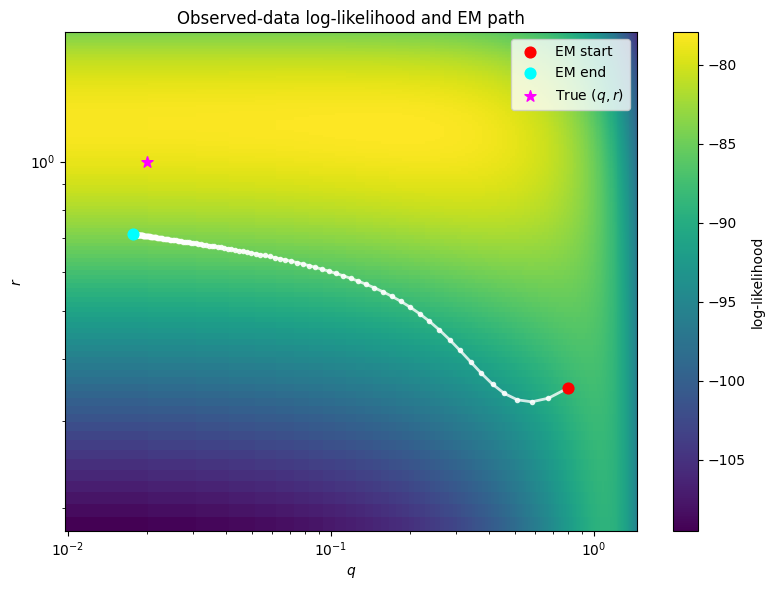

In [19]:
q_true = 0.02
r_true = 1.0

plt.figure(figsize=(8, 6))

plt.imshow(
    Z,
    origin="lower",
    aspect="auto",
    extent=[q_vals[0], q_vals[-1], r_vals[0], r_vals[-1]]
)

plt.colorbar(label="log-likelihood")

path = em_out_qr["path"]
path_q = np.exp(path[:, 0])
path_r = np.exp(path[:, 1])

plt.plot(path_q, path_r, color="white", linewidth=2.0, marker="o", markersize=3, alpha=0.8)
plt.scatter(path_q[0], path_r[0], color="red", s=60, label="EM start", zorder=5)
plt.scatter(path_q[-1], path_r[-1], color="cyan", s=60, label="EM end", zorder=5)
plt.scatter(q_true, r_true, color="magenta", s=70, marker="*", label="True $(q,r)$", zorder=6)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$q$")
plt.ylabel(r"$r$")
plt.title("Observed-data log-likelihood and EM path")
plt.legend()
plt.tight_layout()
plt.show()

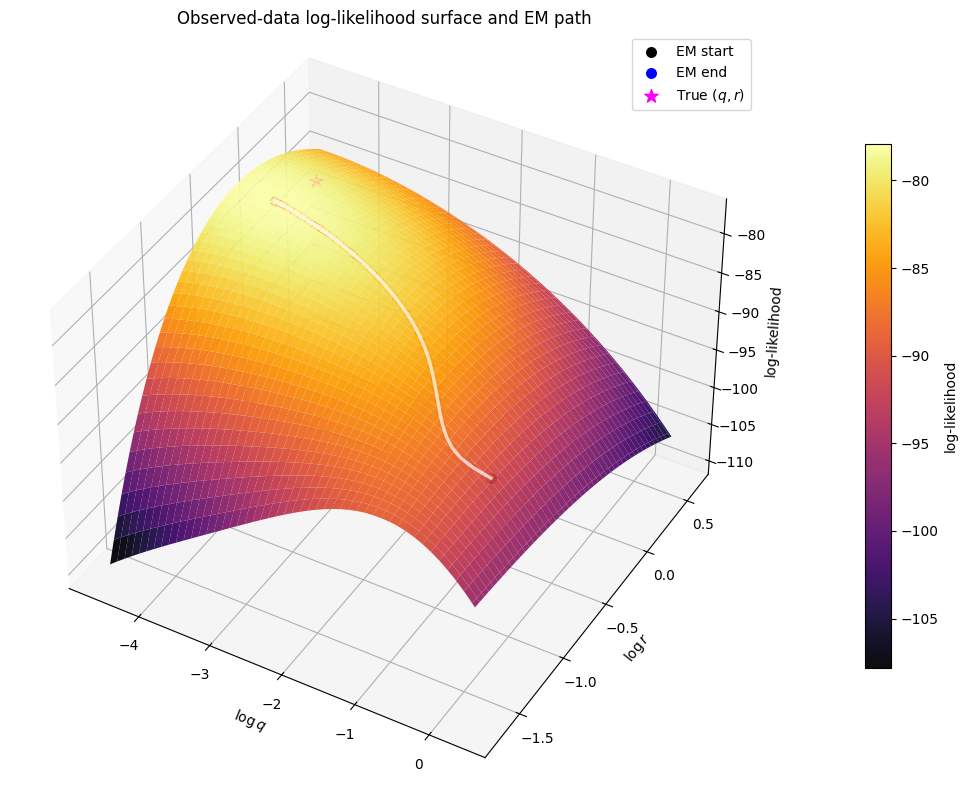

In [20]:
from mpl_toolkits.mplot3d import Axes3D

q_true = 0.02
r_true = 1.0

path = em_out_qr["path"]
path_loglik = np.array([
    kalman_loglik(
        xs=xs,
        F=F,
        Q=make_Q_R(np.exp(lq), np.exp(lr))[0],
        H=H,
        R=make_Q_R(np.exp(lq), np.exp(lr))[1],
        m0=m0,
        C0=C0
    )
    for lq, lr in path
])

true_loglik = kalman_loglik(
    xs=xs,
    F=F,
    Q=make_Q_R(q_true, r_true)[0],
    H=H,
    R=make_Q_R(q_true, r_true)[1],
    m0=m0,
    C0=C0
)

LQ, LR = np.meshgrid(log_q_vals, log_r_vals)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    LQ, LR, Z,
    cmap="inferno",
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

ax.plot(
    path[:, 0],
    path[:, 1],
    path_loglik,
    color="white",
    linewidth=2.5,
    alpha=0.7,
    zorder=10
)
ax.scatter(
    path[:, 0],
    path[:, 1],
    path_loglik,
    color="red",
    s=20,
    alpha=0.6,
    zorder=11
)

ax.scatter(path[0, 0], path[0, 1], path_loglik[0], color="black", s=80, edgecolors="white", linewidth=1, label="EM start", zorder=12)
ax.scatter(path[-1, 0], path[-1, 1], path_loglik[-1], color="blue", s=80, edgecolors="white", linewidth=1, label="EM end")
ax.scatter(np.log(q_true), np.log(r_true), true_loglik, color="magenta", s=100, marker="*", label="True $(q,r)$")

ax.set_xlabel(r"$\log q$")
ax.set_ylabel(r"$\log r$")
ax.set_zlabel("log-likelihood")
ax.set_title("Observed-data log-likelihood surface and EM path")

fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label="log-likelihood")
ax.view_init(elev=40, azim=-60)
ax.legend()

plt.tight_layout()
plt.show()

## Extended Kalman Filter

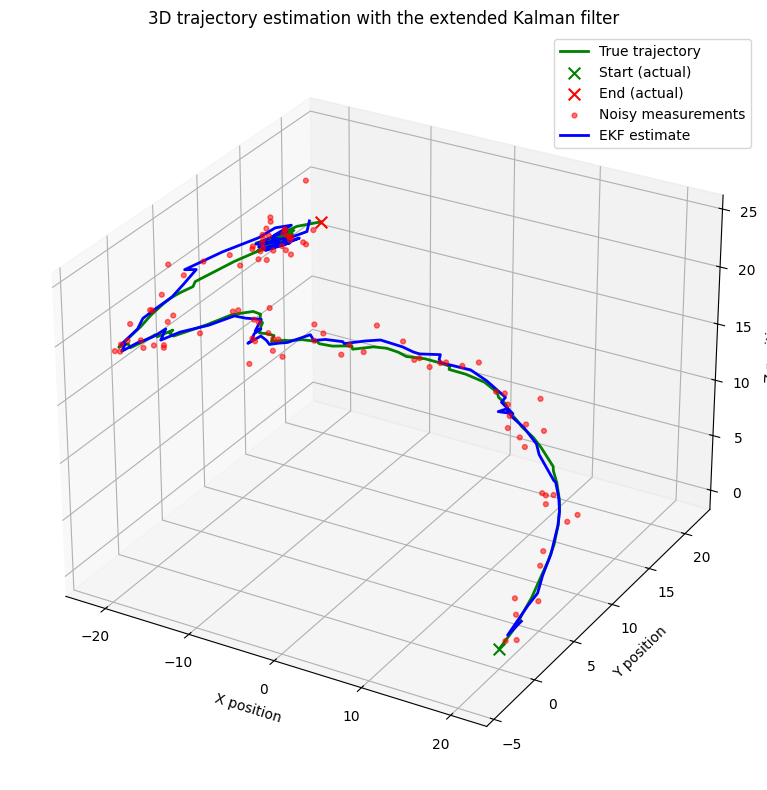

In [21]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

rng = np.random.default_rng(7)

# EKF example: latent angular motion with nonlinear observation
# State: [theta, omega, z, vz]
# Observation: [x, y, z] = [R cos(theta), R sin(theta), z]


T = 100
dt = 1.0
radius = 20.0
obs_std = 1.0

# Linear latent dynamics
F = np.array([
    [1.0, dt, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, dt ],
    [0.0, 0.0, 0.0, 1.0],
])

Q = np.diag([0.002, 0.0003, 0.02, 0.002])
R = (obs_std**2) * np.eye(3)

def wrap_angle(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

def f_helix(s):
    return F @ s

def h_helix(s):
    theta, omega, z, vz = s
    return np.array([
        radius * np.cos(theta),
        radius * np.sin(theta),
        z
    ])

def H_jacobian(s):
    theta, omega, z, vz = s
    return np.array([
        [-radius * np.sin(theta), 0.0, 0.0, 0.0],
        [ radius * np.cos(theta), 0.0, 0.0, 0.0],
        [0.0,                     0.0, 1.0, 0.0],
    ])

# Simulate true latent states
states_true = np.zeros((T, 4))
states_true[0] = np.array([0.0, 0.10, 0.0, 0.5])

for t in range(T - 1):
    w = rng.multivariate_normal(np.zeros(4), Q)
    states_true[t + 1] = f_helix(states_true[t]) + w
    states_true[t + 1, 0] = wrap_angle(states_true[t + 1, 0])

theta_true = states_true[:, 0]
true_z = states_true[:, 2]
true_x = radius * np.cos(theta_true)
true_y = radius * np.sin(theta_true)

# Noisy Cartesian observations
xs_3d = np.column_stack([
    true_x + rng.normal(0.0, obs_std, size=T),
    true_y + rng.normal(0.0, obs_std, size=T),
    true_z + rng.normal(0.0, obs_std, size=T),
])

# EKF initialisation
m_filt = np.zeros((T, 4))
C_filt = np.zeros((T, 4, 4))

m_filt[0] = np.array([0.15, 0.08, xs_3d[0, 2], 0.45])
C_filt[0] = np.diag([0.15, 0.01, 1.0, 0.08])

I4 = np.eye(4)

for t in range(T - 1):
    m_t = m_filt[t]
    C_t = C_filt[t]

    # Prediction
    m_hat = f_helix(m_t)
    C_hat = F @ C_t @ F.T + Q

    # Update
    H_t = H_jacobian(m_hat)
    innovation = xs_3d[t + 1] - h_helix(m_hat)

    S = H_t @ C_hat @ H_t.T + R
    K = C_hat @ H_t.T @ np.linalg.inv(S)

    m_new = m_hat + K @ innovation
    m_new[0] = wrap_angle(m_new[0])

    C_new = (I4 - K @ H_t) @ C_hat @ (I4 - K @ H_t).T + K @ R @ K.T
    C_new = 0.5 * (C_new + C_new.T)

    m_filt[t + 1] = m_new
    C_filt[t + 1] = C_new

# Convert EKF state means into Cartesian coordinates
theta_est = m_filt[:, 0]
z_est = m_filt[:, 2]

x_est = radius * np.cos(theta_est)
y_est = radius * np.sin(theta_est)

# Push EKF covariance into Cartesian position space for ellipsoid plotting
means_xyz = np.zeros((T, 6))
covs_xyz = np.zeros((T, 6, 6))

for t in range(T):
    means_xyz[t, 0] = x_est[t]
    means_xyz[t, 2] = y_est[t]
    means_xyz[t, 4] = z_est[t]

    H_t = H_jacobian(m_filt[t])
    Cpos = H_t @ C_filt[t] @ H_t.T

    covs_xyz[t][np.ix_([0, 2, 4], [0, 2, 4])] = Cpos

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot(true_x, true_y, true_z, color="green", linewidth=2.0, label="True trajectory")
ax.scatter(true_x[0], true_y[0], true_z[0], color="green", marker="x", s=70, label="Start (actual)")
ax.scatter(true_x[-1], true_y[-1], true_z[-1], color="red", marker="x", s=70, label="End (actual)")

ax.scatter(
    xs_3d[:, 0], xs_3d[:, 1], xs_3d[:, 2],
    color="red", s=12, alpha=0.55, depthshade=True,
    label="Noisy measurements"
)

ax.plot(x_est, y_est, z_est, color="blue", linewidth=2.0, label="EKF estimate")

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_zlabel("Z position")
ax.set_title("3D trajectory estimation with the extended Kalman filter")
ax.view_init(elev=28, azim=-60)
ax.legend()


plt.tight_layout()
plt.show()